In [1]:
import importlib.util
import subprocess
import sys

packages = ["pandas", "numpy", "scipy", "statsmodels", "matplotlib", "seaborn"]
missing = [pkg for pkg in packages if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
print("Pustaka siap digunakan.")

Pustaka siap digunakan.


In [2]:
import os
import warnings
from pathlib import Path

Path(".matplotlib").mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.discrete.discrete_model import Logit
from statsmodels.miscmodels.ordinal_model import OrderedModel

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")

In [3]:
data = [[1, 3, 1, 3, 3, 1, 19], [2, 2, 1, 3, 2, 2, 18], [3, 2, 5, 2, 3, 2, 18], [4, 2, 3, 2, 3, 3, 19], [5, 2, 2, 2, 1, 2, 17], [6, 3, 2, 2, 1, 2, 18], [7, 1, 1, 2, 2, 2, 20], [8, 1, 2, 1, 2, 2, 18], [9, 2, 5, 3, 2, 2, 19], [10, 2, 2, 2, 1, 2, 19], [11, 2, 1, 1, 3, 2, 19], [12, 3, 4, 2, 1, 1, 18], [13, 3, 2, 1, 1, 1, 18], [14, 2, 3, 2, 3, 3, 19], [15, 3, 1, 2, 1, 1, 19], [16, 2, 3, 2, 2, 2, 19], [17, 2, 4, 2, 1, 1, 18], [18, 2, 2, 1, 1, 1, 20], [19, 1, 3, 2, 3, 3, 17], [20, 2, 2, 1, 1, 1, 19], [21, 2, 3, 3, 2, 2, 19], [22, 2, 2, 3, 1, 2, 19], [23, 2, 4, 2, 2, 2, 19], [24, 2, 2, 1, 1, 2, 19], [25, 2, 5, 2, 1, 3, 18], [26, 2, 5, 1, 2, 1, 18], [27, 2, 5, 2, 2, 2, 18], [28, 3, 4, 2, 3, 2, 18], [29, 3, 2, 1, 1, 1, 20], [30, 2, 1, 2, 2, 2, 19], [31, 1, 4, 2, 2, 2, 19], [32, 2, 2, 2, 1, 1, 19], [33, 1, 3, 1, 2, 2, 19], [34, 3, 1, 2, 2, 2, 20], [35, 2, 2, 3, 1, 1, 19], [36, 1, 2, 1, 1, 3, 20], [37, 2, 1, 1, 2, 1, 20], [38, 1, 2, 1, 2, 2, 19], [39, 3, 1, 2, 1, 2, 19], [40, 2, 2, 2, 2, 1, 18], [41, 2, 5, 2, 3, 2, 19], [42, 2, 3, 2, 3, 2, 19], [43, 2, 1, 2, 1, 2, 17], [44, 2, 5, 2, 3, 3, 18], [45, 2, 1, 2, 2, 1, 18], [46, 2, 2, 1, 1, 1, 19], [47, 2, 3, 3, 3, 3, 19], [48, 2, 2, 1, 1, 1, 17], [49, 2, 2, 2, 2, 2, 17], [50, 2, 3, 2, 3, 2, 20], [51, 2, 3, 2, 3, 2, 20], [52, 1, 2, 1, 2, 2, 19], [53, 2, 2, 2, 1, 3, 18], [54, 2, 1, 3, 1, 3, 19], [55, 1, 2, 1, 1, 3, 19], [56, 2, 3, 3, 3, 3, 19], [57, 2, 2, 1, 1, 1, 18], [58, 1, 2, 1, 3, 3, 18], [59, 1, 1, 1, 3, 3, 19], [60, 2, 2, 2, 1, 2, 17], [61, 1, 2, 1, 1, 3, 19], [62, 2, 1, 2, 2, 1, 18], [63, 1, 4, 2, 2, 3, 19], [64, 2, 2, 1, 1, 1, 18], [65, 3, 1, 3, 1, 1, 18], [66, 1, 2, 1, 3, 3, 19]]

columns = [
    "no", "kepuasan", "provider", "sinyal",
    "tarif_sms", "tarif_data", "usia"
]
df = pd.DataFrame(data, columns=columns)

assert df.shape == (66, 7)
assert set(df["kepuasan"]) == {1, 2, 3}
assert set(df["provider"]) == {1, 2, 3, 4, 5}

df.to_csv("data_regresi_logistik_ordinal.csv", index=False)
df.head()

,no,kepuasan,provider,sinyal,tarif_sms,tarif_data,usia
0,1,3,1,3,3,1,19
1,2,2,1,3,2,2,18
2,3,2,5,2,3,2,18
3,4,2,3,2,3,3,19
4,5,2,2,2,1,2,17


In [4]:
labels = {
    "kepuasan": {1: "Tidak Puas", 2: "Puas", 3: "Sangat Puas"},
    "provider": {1: "Indosat", 2: "Telkomsel", 3: "Three", 4: "XL", 5: "Axis"},
    "sinyal": {1: "Sangat Kuat", 2: "Kuat", 3: "Lemah"},
    "tarif_sms": {1: "Mahal", 2: "Sedang", 3: "Murah"},
    "tarif_data": {1: "Mahal", 2: "Sedang", 3: "Murah"},
}

print("Jumlah data hilang:")
display(df.isna().sum().to_frame("missing"))

print("Distribusi tingkat kepuasan:")
freq_y = df["kepuasan"].value_counts().sort_index().rename(index=labels["kepuasan"])
display(pd.DataFrame({"n": freq_y, "persen": 100 * freq_y / len(df)}))

display(df[["usia"]].describe())

Jumlah data hilang:


,missing
no,0
kepuasan,0
provider,0
sinyal,0
tarif_sms,0
tarif_data,0
usia,0


Distribusi tingkat kepuasan:


,n,persen
kepuasan,,
Tidak Puas,14,21.2121
Puas,42,63.6364
Sangat Puas,10,15.1515


,usia
count,66.0000
mean,18.6364
std,0.8159
min,17.0000
25%,18.0000
50%,19.0000
75%,19.0000
max,20.0000


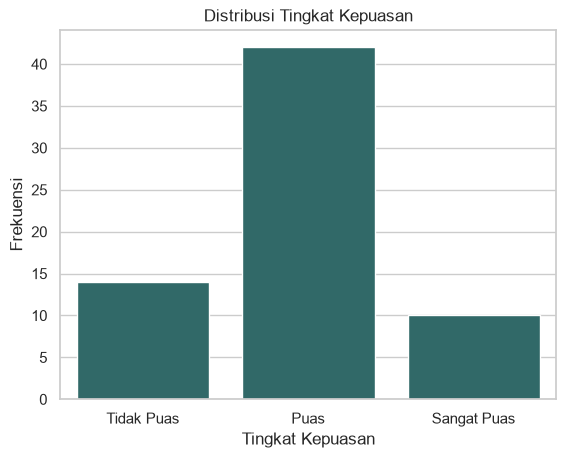

In [5]:
plot_df = df.copy()
plot_df["kepuasan_label"] = plot_df["kepuasan"].map(labels["kepuasan"])
order_y = ["Tidak Puas", "Puas", "Sangat Puas"]

ax = sns.countplot(data=plot_df, x="kepuasan_label", order=order_y, color="#287271")
ax.set(xlabel="Tingkat Kepuasan", ylabel="Frekuensi", title="Distribusi Tingkat Kepuasan")
plt.show()

Model menggunakan dummy `k-1` untuk setiap faktor. Nama seperti `provider_1`
berarti kategori 1 dibandingkan kategori referensi provider 5 (Axis).

In [6]:
factor_cols = ["provider", "sinyal", "tarif_sms", "tarif_data"]
reference = {"provider": 5, "sinyal": 3, "tarif_sms": 3, "tarif_data": 3}

def make_design(dataframe, included=None):
    included = factor_cols + ["usia"] if included is None else included
    parts = []
    for col in included:
        if col == "usia":
            parts.append(dataframe[["usia"]].astype(float))
        else:
            levels = sorted(dataframe[col].unique())
            ref = reference[col]
            for level in levels:
                if level != ref:
                    parts.append(
                        (dataframe[col] == level).astype(float).rename(f"{col}_{level}").to_frame()
                    )
    return pd.concat(parts, axis=1) if parts else pd.DataFrame(index=dataframe.index)

X = make_design(df)
y = df["kepuasan"].astype(int)
display(X.head())

,provider_1,provider_2,provider_3,provider_4,sinyal_1,sinyal_2,tarif_sms_1,tarif_sms_2,tarif_data_1,tarif_data_2,usia
0,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,19.0000
1,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,18.0000
2,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,18.0000
3,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,19.0000
4,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,17.0000


In [7]:
model = OrderedModel(y, X, distr="logit")
result = model.fit(method="bfgs", maxiter=2000, disp=False)
print(result.summary())

                             OrderedModel Results                             
Dep. Variable:               kepuasan   Log-Likelihood:                -31.934
Model:                   OrderedModel   AIC:                             89.87
Method:            Maximum Likelihood   BIC:                             118.3
Date:                Sun, 14 Jun 2026                                         
Time:                        16:39:52                                         
No. Observations:                  66                                         
Df Residuals:                      53                                         
Df Model:                          11                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
provider_1       0.2502      1.289      0.194      0.846      -2.277       2.777
provider_2      -1.4977      1.342     -1.116 

In [8]:
k_beta = X.shape[1]
beta = result.params.iloc[:k_beta]
threshold_raw = result.params.iloc[k_beta:]
threshold = model.transform_threshold_params(threshold_raw)[1:-1]

equation = pd.DataFrame(
    {
        "Komponen": list(beta.index) + ["theta_1", "theta_2"],
        "Estimasi": list(beta.values) + list(threshold),
    }
)
display(equation)

terms = " + ".join([f"({v:.4f}) {name}" for name, v in beta.items()])
print("Bentuk model:")
print(f"logit[P(Y <= j)] = theta_j - [{terms}]")
print(f"theta_1 = {threshold[0]:.4f}; theta_2 = {threshold[1]:.4f}")

,Komponen,Estimasi
0,provider_1,0.2502
1,provider_2,-1.4977
2,provider_3,-0.7830
3,provider_4,-1.0955
4,sinyal_1,-2.8850
5,sinyal_2,-0.3755
6,tarif_sms_1,0.7056
7,tarif_sms_2,-3.2966
8,tarif_data_1,5.8488
9,tarif_data_2,3.8248


Bentuk model:
logit[P(Y <= j)] = theta_j - [(0.2502) provider_1 + (-1.4977) provider_2 + (-0.7830) provider_3 + (-1.0955) provider_4 + (-2.8850) sinyal_1 + (-0.3755) sinyal_2 + (0.7056) tarif_sms_1 + (-3.2966) tarif_sms_2 + (5.8488) tarif_data_1 + (3.8248) tarif_data_2 + (0.1230) usia]
theta_1 = 0.3659; theta_2 = 6.5749


In [9]:
coef_table = pd.DataFrame(
    {
        "B": beta,
        "SE": result.bse.iloc[:k_beta],
        "Wald_z": result.tvalues.iloc[:k_beta],
        "p_value": result.pvalues.iloc[:k_beta],
    }
)
coef_table["OR_kategori_lebih_tinggi"] = np.exp(coef_table["B"])
coef_table["CI95_OR_bawah"] = np.exp(coef_table["B"] - 1.96 * coef_table["SE"])
coef_table["CI95_OR_atas"] = np.exp(coef_table["B"] + 1.96 * coef_table["SE"])
coef_table["signif_5persen"] = np.where(coef_table["p_value"] < 0.05, "Ya", "Tidak")
display(coef_table)

,B,SE,Wald_z,p_value,OR_kategori_lebih_tinggi,CI95_OR_bawah,CI95_OR_atas,signif_5persen
provider_1,0.2502,1.2893,0.1941,0.8461,1.2843,0.1026,16.0733,Tidak
provider_2,-1.4977,1.3420,-1.1160,0.2644,0.2236,0.0161,3.1037,Tidak
provider_3,-0.7830,1.2676,-0.6177,0.5368,0.4570,0.0381,5.4825,Tidak
provider_4,-1.0955,1.4941,-0.7332,0.4634,0.3344,0.0179,6.2527,Tidak
sinyal_1,-2.8850,1.1570,-2.4934,0.0127,0.0559,0.0058,0.5395,Ya
sinyal_2,-0.3755,1.0237,-0.3668,0.7137,0.6869,0.0924,5.1082,Tidak
tarif_sms_1,0.7056,1.1558,0.6105,0.5415,2.0250,0.2102,19.5082,Tidak
tarif_sms_2,-3.2966,1.3556,-2.4318,0.0150,0.0370,0.0026,0.5275,Ya
tarif_data_1,5.8488,1.5400,3.7979,0.0001,346.8269,16.9528,7095.5240,Ya
tarif_data_2,3.8248,1.2929,2.9583,0.0031,45.8238,3.6355,577.5945,Ya


In [10]:
comparison_labels = {
    "provider_1": "Indosat dibanding Axis",
    "provider_2": "Telkomsel dibanding Axis",
    "provider_3": "Three dibanding Axis",
    "provider_4": "XL dibanding Axis",
    "sinyal_1": "sinyal Sangat Kuat dibanding Lemah",
    "sinyal_2": "sinyal Kuat dibanding Lemah",
    "tarif_sms_1": "tarif SMS Mahal dibanding Murah",
    "tarif_sms_2": "tarif SMS Sedang dibanding Murah",
    "tarif_data_1": "tarif data Mahal dibanding Murah",
    "tarif_data_2": "tarif data Sedang dibanding Murah",
    "usia": "kenaikan usia satu tahun",
}

for term, row in coef_table.iterrows():
    direction = "lebih besar" if row["OR_kategori_lebih_tinggi"] > 1 else "lebih kecil"
    significance = "signifikan" if row["p_value"] < 0.05 else "tidak signifikan"
    print(
        f"- {comparison_labels[term]}: odds kepuasan lebih tinggi {direction} "
        f"{row['OR_kategori_lebih_tinggi']:.3f} kali; {significance} "
        f"(p={row['p_value']:.4f})."
    )

- Indosat dibanding Axis: odds kepuasan lebih tinggi lebih besar 1.284 kali; tidak signifikan (p=0.8461).
- Telkomsel dibanding Axis: odds kepuasan lebih tinggi lebih kecil 0.224 kali; tidak signifikan (p=0.2644).
- Three dibanding Axis: odds kepuasan lebih tinggi lebih kecil 0.457 kali; tidak signifikan (p=0.5368).
- XL dibanding Axis: odds kepuasan lebih tinggi lebih kecil 0.334 kali; tidak signifikan (p=0.4634).
- sinyal Sangat Kuat dibanding Lemah: odds kepuasan lebih tinggi lebih kecil 0.056 kali; signifikan (p=0.0127).
- sinyal Kuat dibanding Lemah: odds kepuasan lebih tinggi lebih kecil 0.687 kali; tidak signifikan (p=0.7137).
- tarif SMS Mahal dibanding Murah: odds kepuasan lebih tinggi lebih besar 2.025 kali; tidak signifikan (p=0.5415).
- tarif SMS Sedang dibanding Murah: odds kepuasan lebih tinggi lebih kecil 0.037 kali; signifikan (p=0.0150).
- tarif data Mahal dibanding Murah: odds kepuasan lebih tinggi lebih besar 346.827 kali; signifikan (p=0.0001).
- tarif data Sedang d

In [11]:
null_model = OrderedModel(y, np.ones((len(y), 0)), distr="logit")
null_result = null_model.fit(method="bfgs", maxiter=2000, disp=False)

lr_omnibus = 2 * (result.llf - null_result.llf)
df_omnibus = X.shape[1]
p_omnibus = stats.chi2.sf(lr_omnibus, df_omnibus)

omnibus = pd.DataFrame(
    {
        "-2 Log Likelihood": [-2 * null_result.llf, -2 * result.llf],
    },
    index=["Intercept only", "Final"],
)
display(omnibus)
print(f"Likelihood-ratio chi-square = {lr_omnibus:.4f}")
print(f"df = {df_omnibus}")
print(f"p-value = {p_omnibus:.6f}")

,-2 Log Likelihood
Intercept only,119.1249
Final,63.8689


Likelihood-ratio chi-square = 55.2559
df = 11
p-value = 0.000000


In [12]:
predictors = factor_cols + ["usia"]
partial_rows = []

for predictor in predictors:
    included = [p for p in predictors if p != predictor]
    X_reduced = make_design(df, included)
    reduced_model = OrderedModel(y, X_reduced, distr="logit")
    reduced_result = reduced_model.fit(method="bfgs", maxiter=2000, disp=False)
    lr = 2 * (result.llf - reduced_result.llf)
    df_diff = X.shape[1] - X_reduced.shape[1]
    partial_rows.append(
        {
            "Variabel": predictor,
            "LR_chi_square": lr,
            "df": df_diff,
            "p_value": stats.chi2.sf(lr, df_diff),
        }
    )

partial_tests = pd.DataFrame(partial_rows).set_index("Variabel")
partial_tests["signif_5persen"] = np.where(partial_tests["p_value"] < 0.05, "Ya", "Tidak")
display(partial_tests)

,LR_chi_square,df,p_value,signif_5persen
Variabel,,,,
provider,3.7698,4,0.4381,Tidak
sinyal,9.6102,2,0.0082,Ya
tarif_sms,18.2160,2,0.0001,Ya
tarif_data,28.8822,2,0.0000,Ya
usia,0.0778,1,0.7803,Tidak


Uji drop-term di atas adalah uji parsial **per prediktor**. Ini terutama penting
untuk provider dan faktor tiga kategori, karena seluruh dummy diuji bersama.

In [13]:
pred_prob = pd.DataFrame(
    result.model.predict(result.params),
    columns=["P_Y1", "P_Y2", "P_Y3"],
    index=df.index,
)

pattern_cols = factor_cols + ["usia"]
work = pd.concat([df[pattern_cols + ["kepuasan"]], pred_prob], axis=1)
groups = []

for pattern, group in work.groupby(pattern_cols, sort=False):
    observed = np.array([(group["kepuasan"] == cat).sum() for cat in [1, 2, 3]], dtype=float)
    expected = group[["P_Y1", "P_Y2", "P_Y3"]].sum(axis=0).to_numpy(dtype=float)
    groups.append((observed, expected))

pearson = sum(np.sum((obs - exp) ** 2 / np.clip(exp, 1e-12, None)) for obs, exp in groups)
deviance = 0.0
for obs, exp in groups:
    positive = obs > 0
    deviance += 2 * np.sum(obs[positive] * np.log(obs[positive] / exp[positive]))

n_patterns = len(groups)
gof_df = n_patterns * (3 - 1) - len(result.params)
gof = pd.DataFrame(
    {
        "Chi-Square": [pearson, deviance],
        "df": [gof_df, gof_df],
        "p_value": [stats.chi2.sf(pearson, gof_df), stats.chi2.sf(deviance, gof_df)],
    },
    index=["Pearson", "Deviance"],
)
display(gof)
print(f"Jumlah pola kovariat unik = {n_patterns}")
print("Catatan: banyak pola dengan frekuensi kecil membuat uji GOF asimtotik perlu dibaca hati-hati.")

,Chi-Square,df,p_value
Pearson,61.6626,91,0.9921
Deviance,48.9595,91,0.9999


Jumlah pola kovariat unik = 52
Catatan: banyak pola dengan frekuensi kecil membuat uji GOF asimtotik perlu dibaca hati-hati.


In [14]:
n = len(df)
cox_snell = 1 - np.exp((2 / n) * (null_result.llf - result.llf))
nagelkerke = cox_snell / (1 - np.exp(2 * null_result.llf / n))
mcfadden = 1 - result.llf / null_result.llf

pseudo_r2 = pd.Series(
    {
        "Cox and Snell": cox_snell,
        "Nagelkerke": nagelkerke,
        "McFadden": mcfadden,
    },
    name="Pseudo R-Square",
)
display(pseudo_r2.to_frame())

,Pseudo R-Square
Cox and Snell,0.5671
Nagelkerke,0.6787
McFadden,0.4638


In [15]:
pred_class = pred_prob.to_numpy().argmax(axis=1) + 1
classification = pd.crosstab(
    pd.Series(y.map(labels["kepuasan"]), name="Aktual"),
    pd.Series(pd.Series(pred_class).map(labels["kepuasan"]), name="Prediksi"),
    margins=True,
)
accuracy = np.mean(pred_class == y.to_numpy())
baseline = y.value_counts(normalize=True).max()

display(classification)
print(f"Akurasi model = {accuracy:.2%}")
print(f"Akurasi baseline (selalu menebak kelas mayoritas) = {baseline:.2%}")

Prediksi,Puas,Sangat Puas,Tidak Puas,All
Aktual,,,,
Puas,39,3,0,42
Sangat Puas,5,5,0,10
Tidak Puas,3,0,11,14
All,47,8,11,66


Akurasi model = 83.33%
Akurasi baseline (selalu menebak kelas mayoritas) = 63.64%


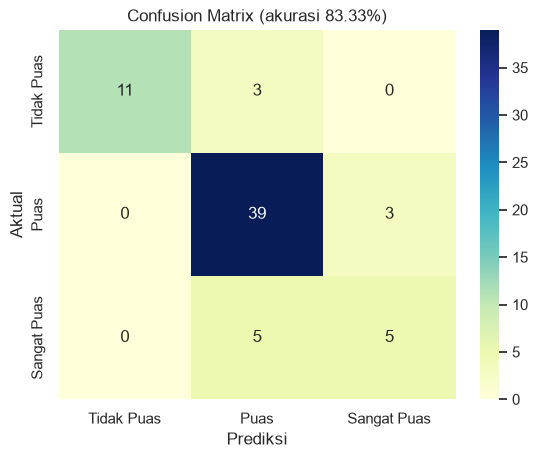

In [16]:
cm = pd.crosstab(
    pd.Categorical(y.map(labels["kepuasan"]), categories=order_y, ordered=True),
    pd.Categorical(pd.Series(pred_class).map(labels["kepuasan"]), categories=order_y, ordered=True),
)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title(f"Confusion Matrix (akurasi {accuracy:.2%})")
plt.show()